# DATA JOURNEY — common notebook (adapter-driven)

Multi-subject extension of `EXPLAIN_COMMON_DELCODE.ipynb`'s single-subject data
journey. Two things this notebook adds on top of the EXPLAIN notebook (it does not
replace it — latent space / separability / logreg-probe / disease-axis cells stay in
EXPLAIN; this notebook is journey + fidelity only):

1. **Multi-subject data journey** — picks `N_PER_CLASS` converters and
   `N_PER_CLASS` stable subjects (default 3 + 3) from the **validation split**
   (`val.csv`, not the pooled train+val `CV_BUNDLE`), ranked by visit count within
   each class, and reruns the full raw-scan → FC → graph → layers →
   reconstruction/prediction → region-importance walkthrough for every selected
   subject in sequence.
2. **Train+validation cohort reconstruction fidelity** — the same
   `adapter.diagnostics(bundle)` call the EXPLAIN notebook already uses on
   `TEST_BUNDLE`, called here on `CV_BUNDLE` (train+val pooled) to characterize
   reconstruction fidelity on the data the encoder was actually fit on.

Same adapter contract as `EXPLAIN_COMMON_DELCODE.ipynb` (`CLASSIFIER/adapters/explain.py`);
meaningful for encoder adapters (`gaae`, `vgae`) since reconstruction fidelity is
undefined for classifiers (the fidelity cell skips with a message for those).

In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
EXPERIMENT_ID = None
MODE = None
MODEL = None
ADAPTER = None                # explain-adapter key; None -> defaults to MODEL
DATASET = None
SEED = 42
GAAE_CHECKPOINT_PATH = None   # GAAE encoder (gaae adapter); None -> interactive pick
SOURCE_EXPERIMENT = None      # classifiers reload outputs/<id>/latest/
THRESHOLD_MODE = None         # unused here (reload uses the saved threshold)
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = None
RESOLVED_CONFIG = None        # merged hyperparameter dict
RUN_DIR = None                # set by the runner: where figures / summary go
RUN_NAME = None               # set by the runner
N_PER_CLASS = 3               # walkthrough cohort size per class (converter / stable)

In [2]:
# Parameters
EXPERIMENT_ID = "data-journey-vgae-gat-anticollapse"
MODE = "data_journey"
MODEL = "VGAE"
DATASET = "DELCODE_WHOLE_BRAIN"
SEED = 42
GAAE_CHECKPOINT_PATH = "notebooks/checkpoints/checkpoints_vgae_whole_brain/VGAE_GAT_ANTICOLLAPSE.pth"
THRESHOLD_MODE = None
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = "outputs/data-journey-vgae-gat-anticollapse"
RESOLVED_CONFIG = {"seed": 100, "batch_size": 64, "learning_rate": 0.00118, "weight_decay": 0.001, "beta": 0.00111, "beta_warmup_epochs": 41, "free_bits": 1.23, "feature_decoder": True, "feature_loss_weight": 2.93, "epochs": 500, "early_stopping_patience": 25, "latent_dim": 64, "hidden_dim": 128, "conv_type": "gat", "checkpoint_tag": "anticollapse", "num_heads": 2, "dropout": 0.3, "adjacency_k": 16, "num_workers": 8, "file_variant": "z_transformed"}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/data-journey-vgae-gat-anticollapse/runs/lucky-river-3-d78a82d34-2026-06-24_10-05-32"
RUN_NAME = "lucky-river-3-d78a82d34-2026-06-24_10-05-32"
ADAPTER = "vgae"


In [3]:
import sys
from pathlib import Path
repo_root = Path('/mnt/e/fyassine/ad-early-detection')
model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(model_root))

In [4]:
# reproducibility seeding — must run before datasets / models.
from CLASSIFIER.common.seeding import set_seed, make_rng, make_torch_generator
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)

In [5]:
import json, os, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from common.checkpoints import select_gaae_checkpoint
from common.sanity import run_full_audit
from common.provenance import region_from_data_root
from common.crossval import Bundle
from common import tracking
from common import explain as ce
from common import pipeline_trace as pt
from adapters.explain import get_explain_adapter

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Imports OK  |  device:', device)

Imports OK  |  device: cuda


## Configuration

In [6]:
from DATA.src.splitting.load_splits import splits_dir, split_csv_paths

WB_DATA_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices'
METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/metadata'
COHORTS_CSV  = os.path.join(METADATA_DIR, 'cohorts.csv')
SPLITS_DIR   = str(splits_dir('downstream'))
TRAIN_CSV = os.path.join(SPLITS_DIR, 'train.csv')
VAL_CSV   = os.path.join(SPLITS_DIR, 'val.csv')
TEST_CSV  = os.path.join(SPLITS_DIR, 'test.csv')

DATA_INFO = region_from_data_root(WB_DATA_ROOT)
REGION = DATA_INFO['region']
print(f"Input data: region={REGION}  atlas={DATA_INFO['atlas']}")

CHECKPOINT_SEARCH_DIRS = [str(model_root / 'notebooks' / 'checkpoints' / 'checkpoints_gaae_whole_brain')]
TRAIN_CONFIG = dict(RESOLVED_CONFIG) if RESOLVED_CONFIG else {}

# GAAE encoder arch (must match the checkpoint).
CONFIG_PATH = model_root / 'configs' / 'gaae_delcode_whole_brain.json'
if CONFIG_PATH.exists():
    hp = json.loads(CONFIG_PATH.read_text())
else:
    hp = dict(latent_dim=64, hidden_dim=128, num_heads=2, cond_dim=2, dropout=0.3,
              adjacency_k=8, file_variant='z_transformed')
print('GAAE config:', hp)

# Where figures / explain_summary.json go.
OUT_DIR = Path(RUN_DIR) if RUN_DIR else (model_root / 'outputs' / (EXPERIMENT_ID or 'explain') / 'standalone')
OUT_DIR.mkdir(parents=True, exist_ok=True)
ATLAS = ce.load_schaefer_atlas()
SUMMARY = {'experiment_id': EXPERIMENT_ID, 'adapter': (ADAPTER or MODEL), 'figures': []}
print('Output dir:', OUT_DIR)

Input data: region=wholebrain  atlas=sch200
GAAE config: {'seed': 100, 'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.001, 'adj_loss_weight': 0.2, 'epochs': 500, 'early_stopping_patience': 25, 'latent_dim': 64, 'hidden_dim': 128, 'num_heads': 2, 'cond_dim': 2, 'dropout': 0.3, 'adjacency_k': 16, 'num_workers': 8, 'file_variant': 'z_transformed'}
Output dir: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/data-journey-vgae-gat-anticollapse/runs/lucky-river-3-d78a82d34-2026-06-24_10-05-32


In [7]:
# split-hygiene audit — hard-fails if any subject crosses splits.
_ = run_full_audit(split_csv_paths('downstream'))

[SANITY] Split sizes: {'train': 99, 'val': 34, 'test': 34}
[SANITY] Pairwise-disjoint: OK


## Resolve adapter & load the trained model

`get_explain_adapter(ADAPTER or MODEL)` returns the explain adapter. `load()` builds
the GAAE encoder (gaae) or reloads `outputs/<SOURCE_EXPERIMENT>/latest/` (classifiers).

In [8]:
ADAPTER_KEY = (ADAPTER or MODEL or '').lower()
# Encoder adapters (gaae / vgae) load a checkpoint directly; classifiers reload a
# trained run via SOURCE_EXPERIMENT instead.
ENCODER_ADAPTERS = {'gaae', 'vgae'}
IS_ENCODER = ADAPTER_KEY in ENCODER_ADAPTERS

GAAE_CKPT = None
if IS_ENCODER:
    if GAAE_CHECKPOINT_PATH is None and RUN_DIR is not None:
        raise ValueError(f"GAAE_CHECKPOINT_PATH (checkpoint_path) is required under the "
                         f"runner for the {ADAPTER_KEY!r} adapter.")
    if ADAPTER_KEY == 'gaae':
        _gaae_name, _gaae_ckpt, _gaae_dir = select_gaae_checkpoint(
            CHECKPOINT_SEARCH_DIRS, checkpoint_path=GAAE_CHECKPOINT_PATH)
        GAAE_CKPT = str(_gaae_ckpt)
        print('GAAE checkpoint:', _gaae_name)
    else:  # vgae: its checkpoints live in their own dir; the path is supplied directly.
        if GAAE_CHECKPOINT_PATH is None:
            raise ValueError("vgae explain needs checkpoint_path to a model.VGAE checkpoint "
                             "(set 'checkpoint_path:' on the the experiments/ directory entry).")
        GAAE_CKPT = str(GAAE_CHECKPOINT_PATH if os.path.isabs(str(GAAE_CHECKPOINT_PATH))
                        else model_root / GAAE_CHECKPOINT_PATH)
        print('VGAE checkpoint:', GAAE_CKPT)

adapter = get_explain_adapter(ADAPTER_KEY)(
    gaae_ckpt_path=GAAE_CKPT, gaae_hp=hp, train_config=TRAIN_CONFIG,
    data_root=WB_DATA_ROOT, cohorts_csv=COHORTS_CSV, device=device, rng=rng,
    source_experiment=SOURCE_EXPERIMENT, classifier_root=model_root)
CAPS = adapter.capabilities
CTX_INFO = adapter.load()
print(f'Adapter: {type(adapter).__name__}  capabilities={sorted(CAPS)}')
print('load():', json.dumps({k: str(v) for k, v in CTX_INFO.items()}, indent=2))

VGAE checkpoint: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_vgae_whole_brain/VGAE_GAT_ANTICOLLAPSE.pth


Adapter: VGAEExplainAdapter  capabilities=['attention', 'reconstruction']
load(): {
  "encoder": "VariationalGraphAutoencoder",
  "conv_type": "gat",
  "vgae_checkpoint": "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_vgae_whole_brain/VGAE_GAT_ANTICOLLAPSE.pth"
}


In [9]:
# Optional W&B run (figures can be logged; off by default unless WANDB_ENABLED).
_wb_exp = {'id': EXPERIMENT_ID or 'explain', 'mode': MODE or 'data_journey',
           'model': MODEL or ADAPTER_KEY, 'dataset': DATASET or REGION,
           'seed': SEED, 'wandb': WANDB_ENABLED}
WANDB_RUN = tracking.init_run(_wb_exp, {**TRAIN_CONFIG, 'REGION': REGION, 'adapter': ADAPTER_KEY, 'RUN_NAME': RUN_NAME})

## Bundles — train+val (pooled), test, and validation-only

In [10]:
train_df = pd.read_csv(TRAIN_CSV); val_df = pd.read_csv(VAL_CSV); test_df = pd.read_csv(TEST_CSV)
cv_pool_df = pd.concat([train_df, val_df], ignore_index=True)

# CV_BUNDLE = train+val pooled (fidelity test below); VAL_BUNDLE = validation split only
# (walkthrough-cohort selection) -- prepare_bundles() is symmetric in its two args, so
# calling it again with val_df alone gives a clean validation-only Bundle.
CV_BUNDLE, TEST_BUNDLE = adapter.prepare_bundles(cv_pool_df, test_df)
VAL_BUNDLE, _ = adapter.prepare_bundles(val_df, test_df)
print(f'Train+val subjects: {len(CV_BUNDLE)}  Test subjects: {len(TEST_BUNDLE)}  '
      f'Validation-only subjects: {len(VAL_BUNDLE)}')

LongitudinalSubjectDataset[v2]: 133 subjects (54 converter, 79 stable MCI)
  Scans per subject: min=1  max=6  mean=3.0


LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=6  mean=2.9


LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=6  mean=2.9


LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=6  mean=2.9


Train+val subjects: 133  Test subjects: 34  Validation-only subjects: 34


## Select walkthrough cohort

Top `N_PER_CLASS` converters + top `N_PER_CLASS` stable subjects from the
**validation split**, ranked by visit count within each class.

In [11]:
items = list(VAL_BUNDLE.items)
n_scans = np.array([int(it.get('n_scans', len(it.get('graphs', [it])))) for it in items])
labels = np.array([int(it['label']) for it in items])


def _top_by_visits(mask, k):
    idx = np.where(mask)[0]
    order = idx[np.argsort(n_scans[idx])[::-1]]
    return order[:k]


conv_idx = _top_by_visits(labels == 1, N_PER_CLASS)
stable_idx = _top_by_visits(labels == 0, N_PER_CLASS)
SELECTED_IDX = np.concatenate([conv_idx, stable_idx])
WALKTHROUGH_BUNDLE = VAL_BUNDLE.subset(SELECTED_IDX)

print(f'Selected {len(conv_idx)} converter(s) + {len(stable_idx)} stable subject(s) '
      f'from validation (ranked by visit count):')
for it in WALKTHROUGH_BUNDLE.items:
    lbl = 'converter' if it['label'] else 'stable_mci'
    print(f"  {it['subject_id']:>14s}  label={lbl:11s}  n_visits={it.get('n_scans')}")

Selected 3 converter(s) + 3 stable subject(s) from validation (ranked by visit count):
       b750d9dbe  label=converter    n_visits=6
       e7967bcd4  label=converter    n_visits=5
       9b16d9da3  label=converter    n_visits=5
       a95bca61d  label=stable_mci   n_visits=6
       278d3e09d  label=stable_mci   n_visits=6
       f99275577  label=stable_mci   n_visits=5


## Per-subject data journey

Repeats the raw-scan → FC → graph → layers → reconstruction/prediction →
region-importance walkthrough (identical to the single-subject version in
`EXPLAIN_COMMON_DELCODE.ipynb`) once per selected subject. Each subject's diagnosis
and visit count are printed before its journey; figures are saved with a
subject-indexed filename and collected into `SUMMARY['walkthrough_subjects']`.

In [12]:
def run_subject_journey(subject, idx, n_total):
    """Run the full single-subject data journey (stages 1-6 + region importance)."""
    base_visit = adapter.baseline_visit(subject)
    print(f"Walkthrough subject {idx}/{n_total}: {subject['subject_id']}  "
          f"label={'converter' if subject['label'] else 'stable_mci'}  "
          f"n_visits={subject.get('n_scans')}  baseline=M{base_visit}")
    trace_raw = pt.nii_to_fc_to_graph(subject['subject_id'], base_visit,
                                      file_variant=hp.get('file_variant', 'z_transformed'),
                                      adjacency_k=hp.get('adjacency_k', 8))
    print('source:', trace_raw['source'])

    # Stage 1-2: raw BOLD volume + Schaefer-200 timeseries.
    if trace_raw.get('bold_img') is not None:
        fig = pt.plot_brain_slice(trace_raw['bold_img'],
                title=f"{subject['subject_id']} \u2014 mean BOLD (M{base_visit})")
        SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, f'journey_{idx}_1_brain')]; plt.close(fig)
        ts = trace_raw['timeseries']
        print('timeseries shape:', ts.shape)
        fig, ax = plt.subplots(figsize=(11, 3.5))
        for r in range(min(6, ts.shape[1])):
            ax.plot(ts[:, r], lw=0.8, alpha=0.8, label=f'ROI {r}')
        ax.set_xlabel('TR'); ax.set_ylabel('z-BOLD'); ax.set_title('Schaefer-200 timeseries (first 6 ROIs)')
        ax.legend(ncol=6, fontsize=7); ax.grid(alpha=0.3)
        SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, f'journey_{idx}_2_timeseries')]; plt.close(fig)
    else:
        print('[skip] raw .nii unavailable \u2014 showing stored FC matrix only (stages 1-2 skipped).')

    # Stage 3: functional-connectivity matrix.
    fig = pt.plot_fc_heatmap(trace_raw['fc_matrix'], trace_raw.get('z_fc'))
    print('FC matrix shape:', np.asarray(trace_raw['x']).shape)
    SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, f'journey_{idx}_3_fc')]; plt.close(fig)

    # Stage 4: kNN brain graph.
    print('edge_index shape:', trace_raw['edge_index'].shape)
    fig = pt.plot_brain_graph(trace_raw['edge_index'], ATLAS, title=f"kNN brain graph \u2014 {subject['subject_id']}")
    SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, f'journey_{idx}_4_graph')]; plt.close(fig)

    # Stage 5: through the model layers (adapter-specific intermediates).
    trace = adapter.trace_forward(subject)
    print('Forward stages:')
    for nm, shp in trace['stages']:
        print(f'  {nm:30s} {tuple(shp)}')

    if 'decoder_gat1' in trace and 'recon' in trace:
        layout = {
            (0, 0): ('x', 'Encoder entry (input x)'),
            (0, 1): ('gat2', 'Encoder pre-latent (gat2)'),
            (0, 2): ('latent', 'Latent z (bottleneck)'),
            (1, 2): ('decoder_gat1', 'Decoder post-latent (decoder_gat1)'),
            (1, 3): ('recon', 'Reconstruction x\u0302'),
        }
        fig, axes = plt.subplots(2, 4, figsize=(20, 8.4))
        for ax in axes.flat:
            ax.axis('off')
        for (r, c), (key, title) in layout.items():
            ax = axes[r, c]; ax.axis('on')
            M = np.asarray(trace[key])
            im = ax.imshow(M, aspect='auto', cmap='viridis')
            ax.set_title(f'{title}\n{M.shape}', fontsize=10)
            ax.set_xlabel('feature'); ax.set_ylabel('node')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.suptitle(f'Encode \u2192 latent \u2192 decode  |  {type(adapter).__name__}')
        fig.tight_layout()
        SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, f'journey_{idx}_5_layers')]
        plt.close(fig)
    elif 'adj_recon' in trace:
        conv_type = CTX_INFO.get('conv_type', '?')
        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
        panels = [
            ('x', 'Encoder entry (input x)'),
            ('latent', f'Latent mu ({conv_type})'),
            ('adj_recon', 'Reconstructed adjacency (sigmoid z z\u1d40)'),
        ]
        for ax, (key, title) in zip(axes, panels):
            M = np.asarray(trace[key])
            im = ax.imshow(M, aspect='auto', cmap='viridis')
            ax.set_title(f'{title}\n{M.shape}', fontsize=10)
            ax.set_xlabel('ROI' if key == 'adj_recon' else 'feature')
            ax.set_ylabel('ROI' if key == 'adj_recon' else 'node')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.suptitle(f'Encode \u2192 latent \u2192 adjacency decode  |  {type(adapter).__name__} ({conv_type})')
        fig.tight_layout()
        SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, f'journey_{idx}_5_layers')]
        plt.close(fig)
    else:
        panels = [(k, trace[k]) for k in ('gat1', 'gat2', 'latent', 'visit_embeddings', 'hidden_states')
                  if k in trace]
        if panels:
            fig, axes = plt.subplots(1, len(panels), figsize=(5.0 * len(panels), 4.2))
            if len(panels) == 1: axes = [axes]
            for ax, (nm, M) in zip(axes, panels):
                M = np.asarray(M)
                im = ax.imshow(M, aspect='auto', cmap='viridis')
                ax.set_title(f'{nm}  {M.shape}'); ax.set_xlabel('feature'); ax.set_ylabel('node / visit')
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            fig.tight_layout()
            SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, f'journey_{idx}_5_layers')]
            plt.close(fig)

    # Stage 5b: input vs reconstruction (200x200) + residual, with a fidelity score.
    fidelity = None
    if 'recon' in trace:
        from model.GAAE.explain import reconstruction_quality

        Q = reconstruction_quality(trace['x'], trace['recon'])
        X_in = np.asarray(trace['x']); X_rec = np.asarray(trace['recon'])
        vmax = float(np.nanpercentile(np.abs(X_in), 99)) or 1.0
        rmax = float(np.nanpercentile(np.abs(Q['residual']), 99)) or 1.0

        fig, axes = plt.subplots(1, 3, figsize=(18, 5.6))
        panels = [
            (axes[0], Q['residual'], -rmax, rmax, f"Residual (x\u0302 \u2212 x)  {Q['residual'].shape}"),
            (axes[1], X_in,          -vmax, vmax, f"Input x  {X_in.shape}"),
            (axes[2], X_rec,         -vmax, vmax, f"Reconstruction x\u0302  {X_rec.shape}"),
        ]
        for ax, M, vlo, vhi, title in panels:
            im = ax.imshow(M, cmap='RdBu_r', vmin=vlo, vmax=vhi, aspect='equal')
            ax.set_title(title); ax.set_xlabel('ROI'); ax.set_ylabel('ROI')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.suptitle(
            f"{subject['subject_id']}   |   r={Q['pearson_r']:.3f}   R\u00b2={Q['r2']:.3f}   "
            f"RMSE={Q['rmse']:.3f}   NRMSE={Q['nrmse']:.2f}   \u2192   {Q['quality'].upper()}",
            fontsize=12,
        )
        fig.tight_layout()
        SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, f'journey_{idx}_5b_recon_compare')]
        plt.close(fig)
        fidelity = {k: Q[k] for k in ('mse', 'rmse', 'mae', 'nrmse', 'pearson_r', 'r2', 'quality')}
        print(f"Reconstruction fidelity: r={Q['pearson_r']:.3f}  R\u00b2={Q['r2']:.3f}  "
              f"quality={Q['quality'].upper()}")
    elif 'adj_recon' in trace:
        from model.GAAE.explain import reconstruction_quality

        Q = reconstruction_quality(trace['adj_true'], trace['adj_recon'])
        A_true, A_rec = np.asarray(trace['adj_true']), np.asarray(trace['adj_recon'])
        rmax = float(np.nanpercentile(np.abs(Q['residual']), 99)) or 1.0

        fig, axes = plt.subplots(1, 3, figsize=(18, 5.6))
        panels = [
            (axes[0], Q['residual'], -rmax, rmax, 'RdBu_r', f"Residual (\u00c2 \u2212 A)  {Q['residual'].shape}"),
            (axes[1], A_true,        0,     1,    'viridis', f"True adjacency A  {A_true.shape}"),
            (axes[2], A_rec,         0,     1,    'viridis', f"Reconstructed adjacency \u00c2  {A_rec.shape}"),
        ]
        for ax, M, vlo, vhi, cmap, title in panels:
            im = ax.imshow(M, cmap=cmap, vmin=vlo, vmax=vhi, aspect='equal')
            ax.set_title(title); ax.set_xlabel('ROI'); ax.set_ylabel('ROI')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        conv_type = CTX_INFO.get('conv_type', '?')
        fig.suptitle(
            f"{subject['subject_id']} ({conv_type})   |   r={Q['pearson_r']:.3f}   R\u00b2={Q['r2']:.3f}   "
            f"RMSE={Q['rmse']:.3f}   NRMSE={Q['nrmse']:.2f}   \u2192   {Q['quality'].upper()}",
            fontsize=12,
        )
        fig.tight_layout()
        SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, f'journey_{idx}_5b_recon_compare')]
        plt.close(fig)
        fidelity = {k: Q[k] for k in ('mse', 'rmse', 'mae', 'nrmse', 'pearson_r', 'r2', 'quality')}
        print(f"Reconstruction fidelity: r={Q['pearson_r']:.3f}  R\u00b2={Q['r2']:.3f}  "
              f"quality={Q['quality'].upper()}")

    # Stage 6: prediction (classifiers) or reconstruction (GAAE / VGAE).
    prediction = None
    if 'probability' in CAPS:
        pred = adapter.predict_one(subject)
        prediction = {**pred, 'subject_id': subject['subject_id']}
        fig, ax = plt.subplots(figsize=(8, 1.7))
        ax.barh([0], [pred['prob']], color='#F44336' if pred['pred'] else '#2196F3', height=0.5)
        ax.axvline(pred['threshold'], color='black', ls='--', label=f"threshold={pred['threshold']:.3f}")
        ax.set_xlim(0, 1); ax.set_yticks([])
        ax.set_title(f"P(converter)={pred['prob']:.3f}  ->  "
                     f"pred={'converter' if pred['pred'] else 'stable'}  "
                     f"(true={'converter' if pred['true'] else 'stable'})")
        ax.legend(loc='lower right')
        SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, f'journey_{idx}_6_prediction')]
        plt.close(fig)
        print(pred)
    else:
        err = adapter.extra('reconstruction', {'subject': subject})['per_node_error']
        print(f'mean per-ROI reconstruction error: {float(err.mean()):.4f}')

    # Region importance ("why").
    region_imp = adapter.region_importance(subject)
    try:
        fig = ce.plot_region_importance_glassbrain(region_imp, ATLAS,
                title=f'Region importance \u2014 {subject["subject_id"]}')
        SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, f'journey_{idx}_7_region_glassbrain')]; plt.close(fig)
    except Exception as exc:
        print('[glass-brain skipped]', exc)
    fig = ce.plot_region_importance_bars(region_imp, ATLAS,
            title=f'Region importance by network \u2014 {subject["subject_id"]}')
    SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, f'journey_{idx}_8_region_bars')]; plt.close(fig)

    SUMMARY['walkthrough_subjects'].append({
        'subject_id': subject['subject_id'],
        'label': int(subject['label']),
        'n_visits': int(subject.get('n_scans', 0)),
        'reconstruction_fidelity': fidelity,
        'prediction': prediction,
    })

In [13]:
SUMMARY['walkthrough_subjects'] = []
n_total = len(WALKTHROUGH_BUNDLE)
for i, subject in enumerate(WALKTHROUGH_BUNDLE.items, 1):
    print(f'\n{"=" * 80}')
    run_subject_journey(subject, i, n_total)


Walkthrough subject 1/6: b750d9dbe  label=converter  n_visits=6  baseline=M0


[fetch_atlas_schaefer_2018] Dataset found in /home/wunderlich/nilearn_data/schaefer_2018

source: nii


timeseries shape: (170, 200)


FC matrix shape: (200, 200)


...

timeseries shape: (170, 200)


FC matrix shape: (200, 200)


edge_index shape: (2, 4068)


Forward stages:
  input x (FC rows)              (200, 200)
  latent mu (gat)                (200, 64)
  pooled graph embedding         (64,)
  true adjacency (kNN graph)     (200, 200)
  reconstructed adjacency (sigmoid z zᵀ) (200, 200)


Reconstruction fidelity: r=0.373  R²=-1.839  quality=POOR
mean per-ROI reconstruction error: 0.7974


## Cohort reconstruction fidelity \u2014 train + validation

Same `adapter.diagnostics(bundle)` contract used by `EXPLAIN_COMMON_DELCODE.ipynb` on
`TEST_BUNDLE`, called here on `CV_BUNDLE` (train+val pooled) to characterize
reconstruction fidelity on the data the encoder was fit on. Only defined for encoder
adapters (`gaae` / `vgae`) \u2014 skips with a message for classifiers. Test-split
fidelity is also computed for side-by-side context.

Train+Val reconstruction error  converter=0.2739  stable=0.2746  one-vs-rest AUC=0.507
Train+Val cohort fidelity (input<->recon Pearson r):  median=0.336  IQR=[0.303, 0.364]  (n=133 subjects)
Test cohort fidelity (context):  median=0.331  IQR=[0.3055169668561215, 0.3472898391628661]  (n=34 subjects)


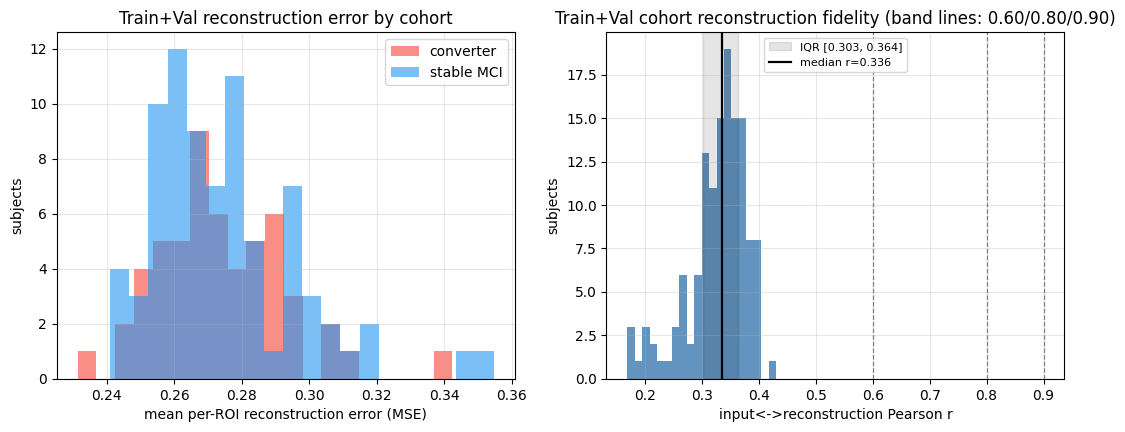

In [14]:
CV_DIAG = adapter.diagnostics(CV_BUNDLE)
if CV_DIAG.get('kind') == 'classification':
    print(f"[skip] reconstruction fidelity is only defined for encoder adapters "
          f"(gaae/vgae); {type(adapter).__name__} is a classifier.")
else:
    TEST_DIAG = adapter.diagnostics(TEST_BUNDLE)
    err, lab = CV_DIAG['recon_error'], CV_DIAG['labels']
    rfid = np.asarray(CV_DIAG['recon_fidelity_r'], dtype=float)
    med, (q1, q3) = CV_DIAG['fidelity_median'], CV_DIAG['fidelity_iqr']
    print(f"Train+Val reconstruction error  converter={CV_DIAG['mean_converter']:.4f}  "
          f"stable={CV_DIAG['mean_stable']:.4f}  one-vs-rest AUC={CV_DIAG['recon_error_auc']:.3f}")
    print(f"Train+Val cohort fidelity (input<->recon Pearson r):  median={med:.3f}  "
          f"IQR=[{q1:.3f}, {q3:.3f}]  (n={rfid.size} subjects)")
    print(f"Test cohort fidelity (context):  median={TEST_DIAG['fidelity_median']:.3f}  "
          f"IQR={TEST_DIAG['fidelity_iqr']}  (n={len(TEST_DIAG['recon_fidelity_r'])} subjects)")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for l, c, nm in [(1, '#F44336', 'converter'), (0, '#2196F3', 'stable MCI')]:
        axes[0].hist(err[lab == l], bins=20, alpha=0.6, color=c, label=nm)
    axes[0].set_xlabel('mean per-ROI reconstruction error (MSE)'); axes[0].set_ylabel('subjects')
    axes[0].legend(); axes[0].set_title('Train+Val reconstruction error by cohort'); axes[0].grid(alpha=0.3)
    axes[1].hist(rfid, bins=20, color='#4682B4', alpha=0.85)
    axes[1].axvspan(q1, q3, color='black', alpha=0.10, label=f'IQR [{q1:.3f}, {q3:.3f}]')
    axes[1].axvline(med, color='black', lw=1.6, label=f'median r={med:.3f}')
    for thr in (0.60, 0.80, 0.90):
        axes[1].axvline(thr, color='grey', ls='--', lw=0.9)
    axes[1].set_xlabel('input<->reconstruction Pearson r'); axes[1].set_ylabel('subjects')
    axes[1].set_title('Train+Val cohort reconstruction fidelity (band lines: 0.60/0.80/0.90)')
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    plt.show()
    SUMMARY['figures'] += [str(p) for p in ce.save_fig(fig, OUT_DIR, 'train_val_diagnostics')]
    SUMMARY['train_val_diagnostics'] = {k: CV_DIAG[k] for k in
                                        ('recon_error_auc', 'mean_converter', 'mean_stable',
                                         'fidelity_median', 'fidelity_iqr')}
    SUMMARY['test_diagnostics'] = {k: TEST_DIAG[k] for k in
                                    ('recon_error_auc', 'mean_converter', 'mean_stable',
                                     'fidelity_median', 'fidelity_iqr')}

## Save explain summary

In [15]:
def _jsonable(o):
    if isinstance(o, (np.floating, np.integer)): return o.item()
    if isinstance(o, np.ndarray): return o.tolist()
    return str(o)

with open(OUT_DIR / 'explain_summary.json', 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=_jsonable)
print('Saved', OUT_DIR / 'explain_summary.json', 'with', len(SUMMARY['figures']), 'figures.')
try:
    tracking.finish_run(WANDB_RUN)
except Exception:
    pass

Saved /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/data-journey-vgae-gat-anticollapse/runs/lucky-river-3-d78a82d34-2026-06-24_10-05-32/explain_summary.json with 98 figures.
